# Exercício Programa de Inteligência Artificial (ACH2016)
## EP Parte 1 - Fundamentos de Deep Learning (MLP e CNN)

**Objetivo:** Este notebook contém o código-base de fundação para a primeira parte do EP. Aqui implementamos o carregamento do conjunto de dados (*Fashion MNIST*) e disponibilizamos duas arquiteturas iniciais simples (um MLP e uma CNN).

A tarefa do grupo é analisar esse ponto de partida, que atinge resultados medianos, e implementar melhorias nas configurações passo a passo em cada etapa abaixo.

### Como Trabalhar com este Notebook
1. O roteiro está dividido em 4 experimentos de MLP, 6 experimentos de CNN e uma comparação final.
2. Em cada etapa, vocês devem implementar o treinamento em Keras, validar os resultados e gerar visualizações. Os gráficos de acurácia e loss são o mínimo sugerido, mas vocês podem incluir outras visualizações e explicações que considerarem úteis. Se necessário, implementem funções auxiliares para organizar o código (por exemplo: treino, validação, avaliação, geração de gráficos, entre outras). Ao final de cada etapa, escrevam uma avaliação dos resultados, com achados interessantes, pontos a melhorar, dificuldades e outras observações pertinentes.
3. É recomendável executar este notebook em ambientes com GPU acessível, como o Google Colab.

In [ ]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Define uma seed fixa para garantir a reproducibilidade dos experimentos.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Leitura do Conjunto de Dados

O código padrão a seguir carrega o conteúdo original. Nas linhas finais, nós artificialmente transformamos os números das cores de tamanho padrão `0-255` para a proporção decimal contínua de `0.0 a 1.0` (uma prática essencial para que a rede neural não sofra com pesos estourados durante o ajuste do gradiente em pixels pretos). 

Note também que separamos 20% do volume de treino para servir como os dados de validação analítica onde a função de perda (*loss*) guiará qual calibração atende a um menor erro médio prático.

In [ ]:
# Carrega e preprocessa o FashionMNIST para treino, validacao e teste.
(x_train_all, y_train_all), (x_test_all, y_test_all) = keras.datasets.fashion_mnist.load_data()

x_train_all = x_train_all.astype('float32') / 255.0
x_test_all = x_test_all.astype('float32') / 255.0

x_train_all = np.expand_dims(x_train_all, axis=-1)
x_test_all = np.expand_dims(x_test_all, axis=-1)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all,
    y_train_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_all,
)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_val:', x_val.shape, 'y_val:', y_val.shape)
print('x_test:', x_test_all.shape, 'y_test:', y_test_all.shape)

In [3]:
def build_naive_cnn():
    """Monta uma CNN baseline simples para servir de ponto de partida."""
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_naive_mlp():
    """Monta um MLP baseline linear para comparacao inicial."""
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
tf.keras.backend.clear_session() # Limpa o grafo de computacao do TensorFlow para evitar sobreposicao de modelos.

naive_cnn = build_naive_cnn()
naive_mlp = build_naive_mlp()

baseline_epochs = 10
baseline_batch_size = 128

hist_naive_cnn = naive_cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=baseline_epochs,
    batch_size=baseline_batch_size,
    verbose=2,
)

hist_naive_mlp = naive_mlp.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=baseline_epochs,
    batch_size=baseline_batch_size,
    verbose=2,
)

_, naive_cnn_test_acc = naive_cnn.evaluate(x_test_all, y_test_all, verbose=0)
_, naive_mlp_test_acc = naive_mlp.evaluate(x_test_all, y_test_all, verbose=0)

In [8]:
print('Baseline naive CNN - acc teste:', round(float(naive_cnn_test_acc), 4))
print('Baseline naive MLP - acc teste:', round(float(naive_mlp_test_acc), 4))

Baseline naive CNN - acc teste: 0.893
Baseline naive MLP - acc teste: 0.8406


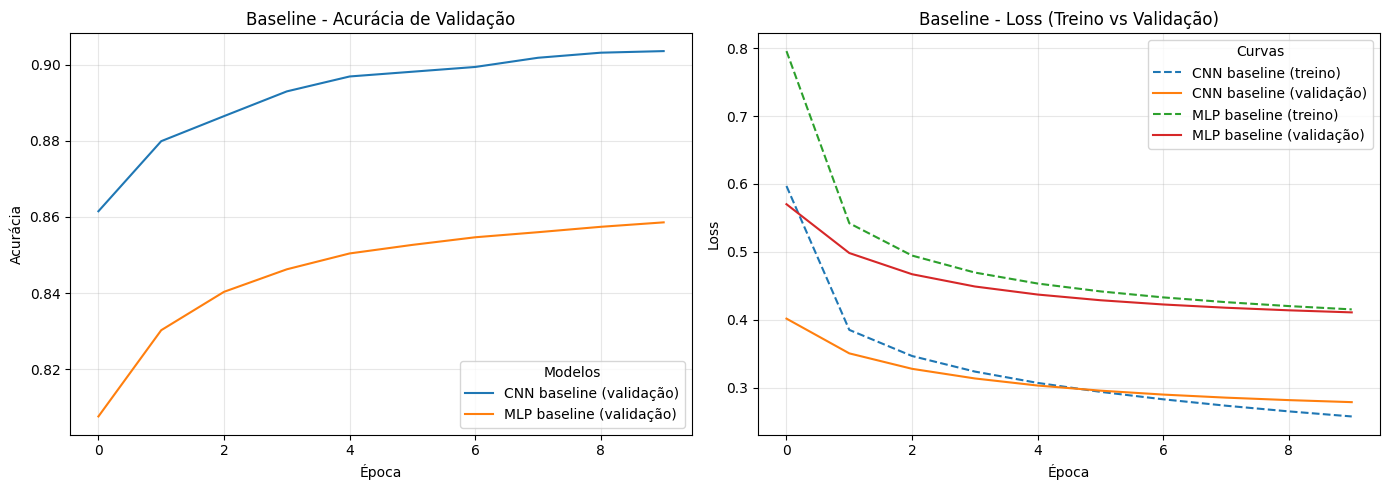

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_naive_cnn.history.get('val_accuracy', []), label='CNN baseline (validação)')
axes[0].plot(hist_naive_mlp.history.get('val_accuracy', []), label='MLP baseline (validação)')
axes[0].set_title('Baseline - Acurácia de Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].grid(alpha=0.3)
axes[0].legend(title='Modelos')

axes[1].plot(hist_naive_cnn.history.get('loss', []), '--', label='CNN baseline (treino)')
axes[1].plot(hist_naive_cnn.history.get('val_loss', []), label='CNN baseline (validação)')
axes[1].plot(hist_naive_mlp.history.get('loss', []), '--', label='MLP baseline (treino)')
axes[1].plot(hist_naive_mlp.history.get('val_loss', []), label='MLP baseline (validação)')
axes[1].set_title('Baseline - Loss (Treino vs Validação)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)
axes[1].legend(title='Curvas')

plt.tight_layout()
plt.show()

# Parte 1: Multilayer Perceptron (MLP)
Nesta parte, vocês vão evoluir o modelo MLP do baseline em quatro etapas.
Em cada questão: implementem os testes, validem os resultados, gerem os gráficos (mínimo: acurácia e loss) e registrem a análise.
Sempre usem a melhor configuração da etapa atual como base para a etapa seguinte.

## Questão MLP 1 (0,5 pts) - Profundidade e Largura (Camadas Ocultas)
O modelo baseline tem um resultado limitado porque é plano. Ele vai direto para a saída (com softmax) e não possui camadas ocultas (hidden layers) para criar abstrações ocultas na rede.

**Tarefas:**
Teste, no mínimo, 3 arquiteturas diferentes variando a quantidade de camadas ocultas.
Inclua pelo menos uma arquitetura rasa, uma intermediária e uma profunda (por exemplo: 1, 2 e 3 camadas ocultas).
Use ReLU nas camadas ocultas e Softmax na saída.
Ao final, escolha a melhor configuração para usar na próxima questão.

In [11]:
# TODO: implemente a Questão MLP 1
# 1) Construa e treine os modelos no Keras com callbacks adequados.
# 2) Valide os resultados no conjunto de validação.
# 3) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 4) Registre a melhor configuração para a próxima questão.

### Resposta MLP 1 (preencher)
- Arquiteturas testadas:
- Melhor configuração escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão MLP 2 (0,5 pts) - Regularização L2
O modelo com mais capacidade pode começar a ajustar demais os dados de treino. A regularização L2 ajuda a controlar pesos muito altos e pode melhorar a generalização.

**Tarefas:**
Use a melhor configuração da Questão 1 como base.
Teste pelo menos três valores de L2 nas camadas densas (por exemplo, 1e-3, 1e-4 e 1e-5).
Compare os resultados e explique como o L2 afetou a convergência e a generalização do modelo.

In [ ]:
# TODO: implemente a Questão MLP 2
# 1) Reaproveite a melhor arquitetura da Questão 1.
# 2) Treine modelos com diferentes valores de L2.
# 3) Valide os resultados e compare os desempenhos.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.

### Resposta MLP 2 (preencher)
- Valores de L2 testados:
- Melhor valor de L2 e configuração escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão MLP 3 (0,5 pts) - Dropout
O dropout desativa aleatoriamente parte dos neurônios durante o treino. Isso reduz a dependência entre ativações e pode diminuir overfitting.

**Tarefas:**
Use a melhor configuração da Questão 2 como base.
Teste o modelo sem dropout e com pelo menos duas taxas de dropout (por exemplo, 0.2 e 0.5).
Compare os resultados e analise o efeito do dropout no overfitting e na convergência.

In [ ]:
# TODO: implemente a Questão MLP 3
# 1) Reaproveite a melhor configuração da Questão 2.
# 2) Treine modelos com diferentes taxas de dropout.
# 3) Valide os resultados e compare os desempenhos.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.

### Resposta MLP 3 (preencher)
- Taxas de dropout testadas:
- Melhor taxa de dropout e configuração escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão MLP 4 (0,5 pts) - Data Augmentation
Data augmentation cria variações das imagens de treino e pode melhorar a robustez do modelo. Nesta etapa, o objetivo é avaliar o efeito dessa técnica no MLP.

**Tarefas:**
Use a melhor configuração da Questão 3 como base.
Compare o desempenho do modelo sem e com data augmentation.
Avalie se a técnica ajudou no MLP e justifique com base nos resultados.

In [ ]:
# TODO: implemente a Questão MLP 4
# 1) Reaproveite a melhor configuração da Questão 3.
# 2) Defina e treine pelo menos 3 estratégias diferentes de data augmentation.
# 3) Valide os resultados e compare os desempenhos entre as estratégias.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.

### Resposta MLP 4 (preencher)
- Configurações comparadas (sem vs com data augmentation):
- Resultado principal da comparação:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

# Parte 2: Redes Neurais Convolucionais (CNN)
Nesta parte, vocês vão evoluir a CNN baseline em seis etapas.
Assim como no MLP, a melhor configuração de cada etapa deve ser usada como base para a etapa seguinte.
Em todas as questões, registrem resultados com gráficos (mínimo: acurácia e loss) e análise objetiva.

## Questão CNN 1 (0,7 pts) - Profundidade (Blocos Conv-Pool)
A CNN baseline começa com poucos blocos de extração. Nesta etapa, o objetivo é medir o efeito da profundidade da rede.

**Tarefas:**
Crie e treine arquiteturas com 1, 2 e 3 blocos Conv2D + MaxPooling2D.
Mantenha os demais hiperparâmetros fixos para comparação justa.
Identifique a melhor profundidade com base em validação e sinais de overfitting.

In [ ]:
# TODO: implemente a Questão CNN 1
# 1) Construa e treine modelos com 1, 2 e 3 blocos Conv2D + MaxPooling2D.
# 2) Mantenha os demais hiperparâmetros fixos para comparação justa.
# 3) Valide os resultados e compare convergência e overfitting.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 5) Registre a melhor configuração para a próxima questão.

### Resposta CNN 1 (preencher)
- Arquiteturas testadas:
- Melhor configuração escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão CNN 2 (0,7 pts) - Largura dos Filtros (Feature Maps)
Com a profundidade definida na Questão 1, agora o foco é calibrar a quantidade de filtros por bloco convolucional.

**Tarefas:**
Teste pelo menos 3 configurações diferentes de filtros por bloco (por exemplo: 16, 32, 64 e 128).
Compare desempenho de validação e custo computacional (tempo de treino e uso de recursos).
Verifique se há ponto de saturação, em que aumentar filtros deixa de trazer ganho relevante.

In [ ]:
# TODO: implemente a Questão CNN 2
# 1) Reaproveite a melhor configuração da Questão CNN 1.
# 2) Teste pelo menos 3 configurações diferentes de filtros (feature maps).
# 3) Compare desempenho em validação e custo computacional.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 5) Registre a melhor configuração para a próxima questão.

### Resposta CNN 2 (preencher)
- Configurações de filtros testadas:
- Melhor configuração escolhida para a próxima etapa:
- Impacto em custo computacional (tempo/recursos):
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão CNN 3 (0,7 pts) - Camada Densa Final
Depois da extração convolucional e do Flatten, a camada densa final consolida as características aprendidas.

**Tarefas:**
Use a melhor configuração da Questão 2 como base.
Teste pelo menos 3 valores de neurônios na camada densa final.
Compare os resultados e escolha o melhor equilíbrio entre desempenho e estabilidade de treino.

In [ ]:
# TODO: implemente a Questão CNN 3
# 1) Reaproveite a melhor configuração da Questão CNN 2.
# 2) Teste pelo menos 3 valores de neurônios na camada densa final.
# 3) Valide os resultados e compare estabilidade e desempenho.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 5) Registre a melhor configuração para a próxima questão.

### Resposta CNN 3 (preencher)
- Valores de neurônios testados na camada densa:
- Melhor configuração escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão CNN 4 (0,7 pts) - Dropout
Nesta etapa, o objetivo é avaliar o impacto do dropout na CNN, usando como base a melhor configuração da Questão 3.

**Tarefas:**
Teste o modelo sem dropout e com pelo menos duas taxas de dropout.
Insira o dropout próximo da camada densa final e mantenha os demais parâmetros fixos.
Compare os resultados e identifique a taxa mais adequada.

In [ ]:
# TODO: implemente a Questão CNN 4
# 1) Reaproveite a melhor configuração da Questão CNN 3.
# 2) Teste o modelo sem dropout e com pelo menos duas taxas de dropout.
# 3) Valide os resultados e compare desempenho e overfitting.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 5) Registre a melhor configuração para a próxima questão.

### Resposta CNN 4 (preencher)
- Taxas de dropout testadas (incluindo 0.0):
- Melhor taxa de dropout escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão CNN 5 (0,7 pts) - Batch Normalization
Batch Normalization pode estabilizar o treinamento e acelerar a convergência em redes convolucionais.

**Tarefas:**
Use a melhor configuração da Questão 4 como base.
Compare versões com e sem Batch Normalization, mantendo os demais parâmetros fixos.
Analise o efeito na estabilidade das curvas, na velocidade de convergência e no desempenho final.

In [ ]:
# TODO: implemente a Questão CNN 5
# 1) Reaproveite a melhor configuração da Questão CNN 4.
# 2) Compare versões com e sem Batch Normalization mantendo os demais parâmetros.
# 3) Valide os resultados e compare estabilidade e velocidade de convergência.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 5) Registre a melhor configuração para a próxima questão.

### Resposta CNN 5 (preencher)
- Configurações comparadas (com vs sem Batch Normalization):
- Melhor configuração escolhida para a próxima etapa:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

## Questão CNN 6 (0,7 pts) - Data Augmentation
A CNN tende a aproveitar melhor transformações visuais do que modelos totalmente densos. Nesta etapa, o objetivo é medir esse ganho na prática.

**Tarefas:**
Use a melhor configuração da Questão 5 como base.
Teste pelo menos 3 estratégias de data augmentation (por exemplo: rotação; rotação + zoom; rotação + translação).
Compare os resultados e justifique qual estratégia foi mais adequada para a CNN.

In [ ]:
# TODO: implemente a Questão CNN 6
# 1) Reaproveite a melhor configuração da Questão CNN 5.
# 2) Teste pelo menos 3 estratégias diferentes de data augmentation.
# 3) Valide os resultados e compare os desempenhos entre as estratégias.
# 4) Gere, no mínimo, os gráficos de acurácia e loss por época.
# 5) Registre a melhor configuração final da CNN.

### Resposta CNN 6 (preencher)
- Estratégias de data augmentation testadas:
- Melhor estratégia escolhida para o modelo final:
- O que os gráficos de acurácia e loss mostram:
- Principais achados, dificuldades e pontos a melhorar:

# Análise Final (1,8 pts) - MLP vs CNN
Nesta etapa, vocês devem comparar os melhores modelos das duas abordagens no conjunto de teste.

**Tarefas:**
Definam as configurações finais do MLP e da CNN com base nas etapas anteriores.
Treinem os dois modelos finais, comparem as métricas e organizem os resultados em tabela.
Gere matriz de confusão (ou heatmap) para os dois modelos e analise os principais padrões de erro.

In [12]:
# TODO: implemente a Análise Final (MLP vs CNN)
# 1) Defina best_cnn_final_cfg e best_mlp_final_cfg com base nas melhores etapas anteriores.
# 2) Treine os dois modelos finais (CNN e MLP) no mesmo protocolo de treino.
# 3) Avalie ambos no conjunto de teste.
# 4) Monte uma tabela comparativa com, no mínimo, as métricas:
#    - acc_teste
#    - precision_macro, recall_macro, f1_macro
#    - precision_weighted, recall_weighted, f1_weighted
# 5) Gere e compare o classification_report por classe para CNN e MLP.
# 6) Gere matriz de confusão (ou heatmap) dos dois modelos e identifique as classes com maior confusão.
# 7) Escreva a conclusão final justificando qual abordagem foi melhor e por quê.
# Dica: use classification_report(..., output_dict=True) para montar a tabela comparativa.

### Relatório Final (preencher)
- Principais aprendizados técnicos:
- Melhor configuração final para CNN:
- Melhor configuração final para MLP:
- Comparação final entre abordagens:
- Qual abordagem teve melhor desempenho final e por quê:
- Principais classes com confusão na CNN:
- Principais classes com confusão no MLP:
- Há relação entre os erros e classes visualmente parecidas:
- Limites do estudo e trabalhos futuros:
- Conclusão geral do grupo:

# Bônus Acadêmico (+1,0 ponto extra)
Espaço livre para experimentos extras do grupo.

Para este bônus, realizem pelo menos um experimento para MLP e um experimento para CNN com alguma das técnicas listadas abaixo ou outra técnica do seu interesse:
- Busca de hiperparâmetros com Keras Tuner ou Optuna.
- Teste de outros otimizadores e schedulers (por exemplo: AdamW, Nadam, decaimento de learning rate).
- Técnicas adicionais de augmentation ou regularização (por exemplo: MixUp, CutMix).
- Variações arquiteturais além do escopo obrigatório.

Cada experimento de bônus deve incluir objetivo, método, resultados (gráficos/tabelas) e análise.